In [1]:
analysis_year = 2023
traffic_rel_path = "Data/Trafficdata/traffic_23.csv"

In [2]:
from pathlib import Path
import platform
import re

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

project_root = Path.cwd().resolve()
if not (project_root / traffic_rel_path).exists() and (project_root.parent / traffic_rel_path).exists():
    project_root = project_root.parent

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "Malgun Gothic"

plt.rcParams["axes.unicode_minus"] = False


In [3]:
traffic_path = project_root / traffic_rel_path
festival_path = project_root / "Data/festival.csv"

def extract_festival_dates(festival_df, year):
    year_df = festival_df[festival_df["연도"] == year].copy()
    festival_dates = set()

    for period in year_df["개최기간"].fillna(""):
        text = re.sub(r"\([^)]*\)", "", str(period))
        text = re.sub(r"\s+", "", text)
        parts = re.split(r"[/,]", text)

        for part in parts:
            if not part:
                continue

            if "~" in part:
                match = re.fullmatch(r"(\d{1,2})\.(\d{1,2})\.?~(\d{1,2})\.(\d{1,2})\.?", part)
                if not match:
                    continue
                start_month, start_day, end_month, end_day = map(int, match.groups())
                start_date = pd.Timestamp(year=year, month=start_month, day=start_day)
                end_date = pd.Timestamp(year=year, month=end_month, day=end_day)
                if start_date <= end_date:
                    festival_dates.update(pd.date_range(start_date, end_date, freq="D"))
            else:
                match = re.fullmatch(r"(\d{1,2})\.(\d{1,2})\.?", part)
                if not match:
                    continue
                month, day = map(int, match.groups())
                festival_dates.add(pd.Timestamp(year=year, month=month, day=day))

    return pd.DatetimeIndex(sorted(festival_dates))

traffic_df = pd.read_csv(traffic_path)
traffic_df["일자"] = pd.to_datetime(traffic_df["일자"].astype(str), format="%Y%m%d")
festival_df = pd.read_csv(festival_path)
festival_dates = extract_festival_dates(festival_df, analysis_year)

hour_cols = [col for col in [f"{hour}시" for hour in range(6, 24)] if col in traffic_df.columns]
selected_bridges = ["서강대교", "마포대교", "원효대교"]

filtered_df = traffic_df[
    traffic_df["지점명"].isin(selected_bridges) & (traffic_df["방향"] == "유입")
].copy()

is_weekend = filtered_df["일자"].dt.weekday >= 5
is_festival = filtered_df["일자"].dt.normalize().isin(festival_dates)

filtered_df["날짜타입"] = "평일"
filtered_df.loc[is_weekend, "날짜타입"] = "주말"
filtered_df.loc[is_festival & ~is_weekend, "날짜타입"] = "축제-평일"
filtered_df.loc[is_festival & is_weekend, "날짜타입"] = "축제-주말"

cleaned_df = filtered_df[["지점명", "일자", "날짜타입"] + hour_cols].copy()
display(cleaned_df.head())


,지점명,일자,날짜타입,6시,7시,8시,9시,10시,11시,12시,...,14시,15시,16시,17시,18시,19시,20시,21시,22시,23시
0,서강대교,2023-01-01,주말,164.0,255.0,534.0,526.0,759.0,660.0,816.0,...,879.0,796.0,798.0,760.0,539.0,451.0,445.0,413.0,257.0,168.0
2,마포대교,2023-01-01,주말,848.0,962.0,1618.0,1577.0,2332.0,2255.0,2403.0,...,2617.0,2528.0,2407.0,2462.0,2234.0,1993.0,1844.0,1671.0,1172.0,761.0
4,원효대교,2023-01-01,주말,302.0,401.0,782.0,792.0,1097.0,999.0,1051.0,...,1281.0,1164.0,1009.0,964.0,823.0,758.0,791.0,754.0,459.0,320.0
8,서강대교,2023-01-02,평일,558.0,828.0,1155.0,1309.0,925.0,825.0,762.0,...,828.0,952.0,968.0,1371.0,1904.0,1176.0,678.0,571.0,431.0,273.0
10,마포대교,2023-01-02,평일,2937.0,3817.0,4034.0,3489.0,3173.0,2819.0,2527.0,...,2983.0,2964.0,3151.0,3806.0,4472.0,3279.0,2551.0,2257.0,1782.0,1225.0


In [4]:
station_avg_df = (
    cleaned_df
    .groupby(["지점명", "날짜타입"], as_index=False)[hour_cols]
    .mean()
)

median_df = station_avg_df.melt(
    id_vars=["지점명", "날짜타입"],
    value_vars=hour_cols,
    var_name="시간",
    value_name="평균유입량",
)
median_df["시간_순서"] = median_df["시간"].str.extract(r"(\d+)").astype(int)
median_df = (
    median_df
    .groupby(["날짜타입", "시간", "시간_순서"], as_index=False)["평균유입량"]
    .median()
    .rename(columns={"평균유입량": "중앙값"})
    .sort_values(["날짜타입", "시간_순서"])
    .reset_index(drop=True)
)

display(station_avg_df.head())
display(median_df.head())


,지점명,날짜타입,6시,7시,8시,9시,10시,11시,12시,13시,14시,15시,16시,17시,18시,19시,20시,21시,22시,23시
0,마포대교,주말,1372.650000,1490.600000,2091.126582,2583.468354,3022.937500,3144.300000,3236.262500,3182.900000,3171.150000,3109.275000,3158.662500,3053.150000,2755.825000,2510.212500,2594.175000,2143.637500,1764.325000,1147.675000
1,마포대교,축제-주말,1388.280000,1487.680000,2156.880000,2755.920000,3201.680000,3237.040000,3284.920000,3201.200000,3109.440000,3033.640000,3082.520000,2979.280000,2760.360000,2542.080000,2680.240000,2309.160000,1878.800000,1235.880000
2,마포대교,축제-평일,2671.519231,3545.250000,3744.250000,3714.173077,3542.500000,3435.730769,3090.096154,3257.826923,3263.730769,3194.230769,3384.115385,3819.711538,3744.500000,3085.230769,2818.307692,2648.846154,2244.442308,1576.480769
3,마포대교,평일,2828.276699,3801.354369,4001.771845,3856.980583,3647.117073,3525.058824,3098.756098,3330.429268,3326.703883,3211.533981,3445.165049,3972.665049,3963.786408,3173.572816,2837.791262,2658.004854,2234.092233,1595.804878
4,서강대교,주말,272.051282,361.833333,572.089744,748.115385,906.769231,947.435897,1062.202532,1099.151899,1133.582278,1101.405063,1099.670886,1033.670886,854.708861,641.784810,543.493671,507.936709,395.000000,265.075949


,날짜타입,시간,시간_순서,중앙값
0,주말,6시,6,530.551282
1,주말,7시,7,672.987179
2,주말,8시,8,950.705128
3,주말,9시,9,1222.705128
4,주말,10시,10,1538.153846


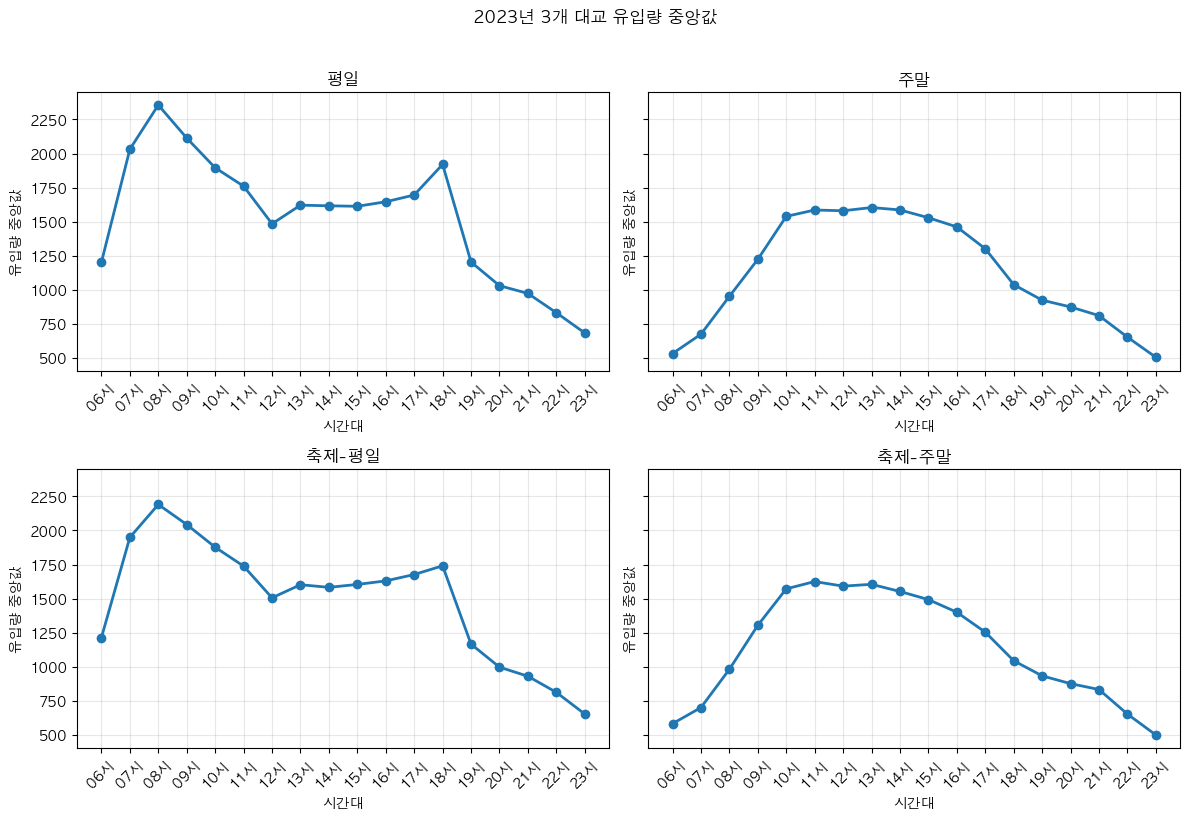

In [5]:
plot_order = ["평일", "주말", "축제-평일", "축제-주말"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)

for ax, date_type in zip(axes.flatten(), plot_order):
    subset = median_df[median_df["날짜타입"] == date_type].sort_values("시간_순서")

    if subset.empty:
        ax.set_title(f"{date_type} (데이터 없음)")
        ax.axis("off")
        continue

    ax.plot(subset["시간_순서"], subset["중앙값"], marker="o", linewidth=2)
    ax.set_title(date_type)
    ax.set_xlabel("시간대")
    ax.set_ylabel("유입량 중앙값")
    ax.set_xticks(range(6, 24))
    ax.set_xticklabels([f"{hour:02d}시" for hour in range(6, 24)], rotation=45)
    ax.grid(alpha=0.3)

fig.suptitle(f"{analysis_year}년 3개 대교 유입량 중앙값", y=1.02)
fig.tight_layout()
plt.show()
